# Bloomberg Dataset Analysis

This notebook is used to clean the Bloomberg Financial News dataset. You can run `bloomberg_data_download.py` to download the raw dataset to use this notebook.

## Setup

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Get the current directory
current_dir = Path.cwd()

# Go up one level to FYP
project_root = current_dir.parent.parent.parent
sys.path.append(str(project_root))
data_path = project_root / "data" / "raw" / "reuters" / "reuters_financial_data.parquet"

# Read the dataset
df = pd.read_parquet(data_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (105359, 6)


,Headline,Journalists,Date,Link,Summary,Article
0,"Hitachi, GE boost alliance in nuclear power bu...",[],"Mon Nov 13, 2006 3:16am EST",http://www.reuters.com/article/2006/11/13/us-e...,TOKYO - Hitachi Ltd. ( 6501.T ) said on Monda...,The move comes a month after France's Areva C...
1,"Volvo to cut 1,000 staff at Virginia plant",[],"Mon Nov 13, 2006 8:45am EST",http://www.reuters.com/article/2006/11/13/us-a...,STOCKHOLM - Truck maker Volvo said on Monday ...,After years of strong demand truck makers see...
2,European banks hiding full pension obligations,[Andrew Hurst],"Mon Nov 13, 2006 3:15am EST",http://www.reuters.com/article/2006/11/13/us-f...,"ZURICH, Nov 13 (Reuter) - West European banks...",Since adopting International Financial Report...
3,"Hitachi, GE to form joint nuclear power ventures",[Mayumi Negishi],"Mon Nov 13, 2006 7:13am EST",http://www.reuters.com/article/2006/11/13/us-e...,TOKYO - Japan's Hitachi Ltd. and U.S. group G...,"The partnership would help Hitachi, Japan's b..."
4,Eddie Bauer agrees to be bought for $286 million,[],"Mon Nov 13, 2006 7:29am EST",http://www.reuters.com/article/2006/11/13/us-r...,- Eddie Bauer Holdings Inc. EBHI.O said and i...,The cash deal is expected to provide Eddie Ba...


# Token counting
Since we will use NLP model to extract feature, it is important to understant the token count before we input

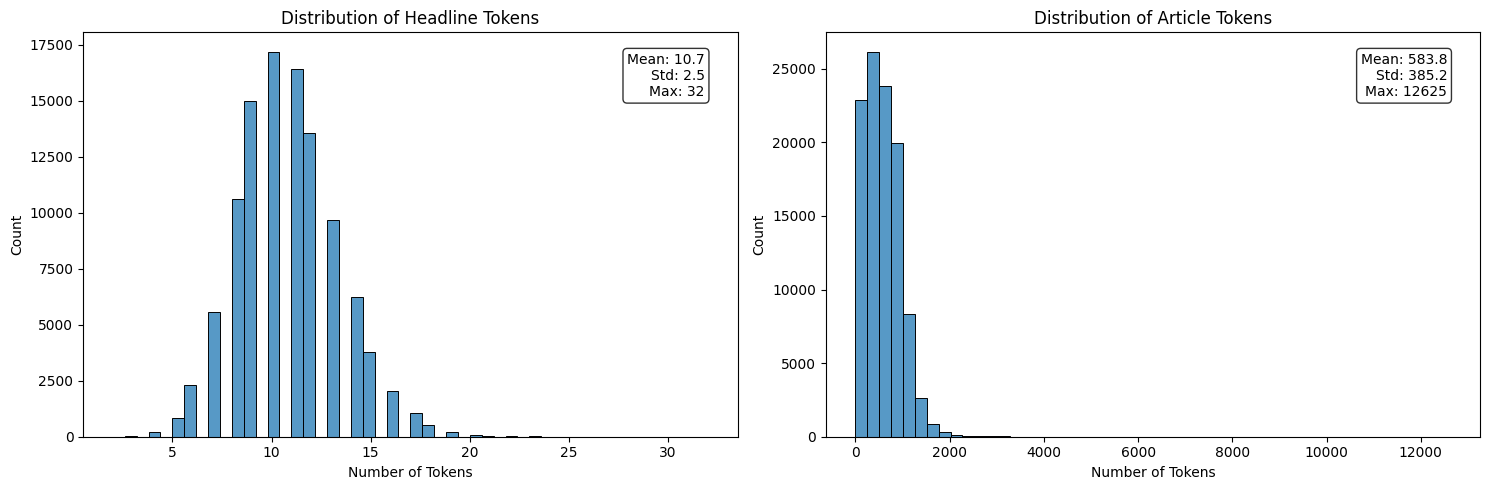


Headline Token Statistics:
count    105359.000000
mean         10.722710
std           2.521123
min           2.000000
25%           9.000000
50%          11.000000
75%          12.000000
max          32.000000
Name: Headline, dtype: float64

Article Token Statistics:
count    105359.000000
mean        583.768221
std         385.249586
min           0.000000
25%         284.000000
50%         543.000000
75%         824.000000
max       12625.000000
Name: Article, dtype: float64


In [3]:
from src.utils.plot_df import plot_token_distribution, print_token_statistics

# Plot distributions
plot_token_distribution(df, ['Headline', 'Article'])

# Print statistics
print_token_statistics(df, ['Headline', 'Article'])

# Distribution by day

/Users/jasonlam/Desktop/github/FYP/src/utils/data_format.py:54: FutureWarning: Parsed string "Mon Nov 13, 2006 3:16am EST" included an un-recognized timezone "EST". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df[column_name] = pd.to_datetime(df[column_name], errors='coerce')


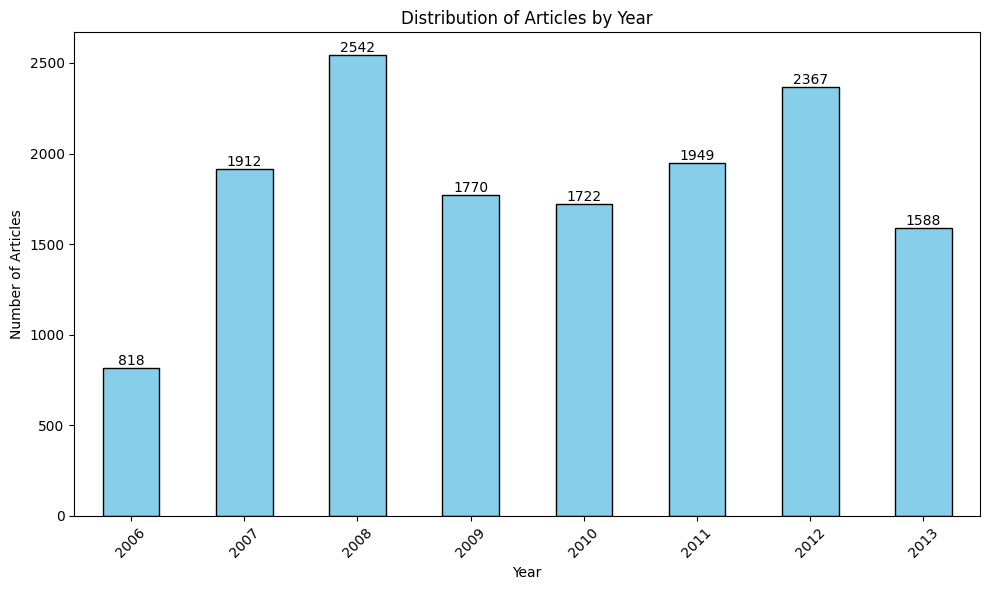

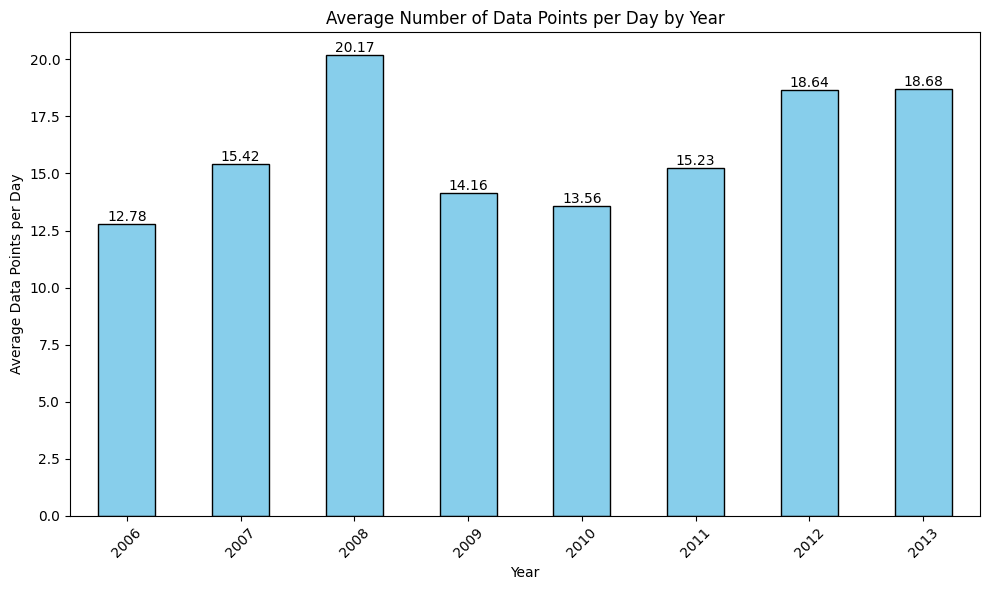

In [4]:
from src.utils.plot_df import plot_distribution_by_year, plot_description_length_distribution, plot_avg_per_day_by_year
from src.utils.data_format import convert_datetime_column

df = convert_datetime_column(df, 'Date')
plot_distribution_by_year(df, 'Date')
plot_avg_per_day_by_year(df, 'Date')

# Data Cleaning
We found that using the `Headline` as the input to the model is practical. This session remove unrelated column to reduce the size of the df in term of the resource and performance.

In [5]:
# Sort by date and remove duplicate headlines
print(f"Original dataset shape: {df.shape}")
old_count = df.shape[0]

# Sort by date in ascending order
cleaned_df = df.sort_values('Date')

# Remove duplicates based on headline, keeping the first occurrence
cleaned_df = cleaned_df.drop_duplicates(subset=['Headline', 'Summary'])

# Select and keep specific columns to CSV
columns_to_keep = ['Headline', 'Date']
cleaned_df = cleaned_df[columns_to_keep]

# Print results
print(f"Dataset shape after removing duplicates: {cleaned_df.shape}")
print(f"Number of duplicates removed: {old_count - cleaned_df.shape[0]}")

# Display the first few rows to verify the sorting
cleaned_df.head()

Original dataset shape: (14668, 6)
Dataset shape after removing duplicates: (14432, 2)
Number of duplicates removed: 236


,Headline,Date
38883,Foreign firms bow to Bolivia energy nationaliz...,2006-10-29 06:40:00-05:00
70350,Wells Fargo exec sees more green home improvement,2006-10-30 01:17:00-05:00
70364,"Hyundai, Kia profit hit by weaker sales, won",2006-10-30 01:25:00-05:00
70352,Online gaming firm 888 says in tie-up talks,2006-10-30 02:52:00-05:00
70356,Homeowners think green on improvements: survey,2006-10-30 03:47:00-05:00


# List date range

In [7]:
# Convert Date column to datetime if not already
cleaned_df['Date'] = pd.to_datetime(df['Date'])

# Get min and max dates
min_date = cleaned_df['Date'].min()
max_date = cleaned_df['Date'].max()

print(f"Date range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total number of days: {(max_date - min_date).days}")

Date range: 2006-10-29 to 2013-11-19
Total number of days: 2578


# Lowercase the column name

In [6]:
# Convert column names to lowercase
cleaned_df.columns = cleaned_df.columns.str.lower()

# Save to csv


In [10]:
SAVE_PATH = project_root / "data" / "processed" / "reuters" 
cleaned_df.to_csv(str(SAVE_PATH) + "/cleaned.csv", index=False)
cleaned_df.head()

,headline,date,Date
38883,Foreign firms bow to Bolivia energy nationaliz...,2006-10-29 06:40:00-05:00,2006-10-29 06:40:00-05:00
70350,Wells Fargo exec sees more green home improvement,2006-10-30 01:17:00-05:00,2006-10-30 01:17:00-05:00
70364,"Hyundai, Kia profit hit by weaker sales, won",2006-10-30 01:25:00-05:00,2006-10-30 01:25:00-05:00
70352,Online gaming firm 888 says in tie-up talks,2006-10-30 02:52:00-05:00,2006-10-30 02:52:00-05:00
70356,Homeowners think green on improvements: survey,2006-10-30 03:47:00-05:00,2006-10-30 03:47:00-05:00
